# Lab 24: World Population and Poverty

In this project, you'll explore data from [Gapminder.org](http://gapminder.org), a website dedicated to providing a fact-based view of the world and how it has changed. That site includes several data visualizations and presentations, but also publishes the raw data that we will use in this project to recreate and extend some of their most famous visualizations.

The Gapminder website collects data from many sources and compiles them into tables that describe many countries around the world. All of the data they aggregate are published in the [Systema Globalis](https://github.com/open-numbers/ddf--gapminder--systema_globalis/blob/master/README.md). Their goal is "to compile all public statistics; Social, Economic and Environmental; into a comparable total dataset." All data sets in this project are copied directly from the Systema Globalis without any changes.

This project is dedicated to [Hans Rosling](https://en.wikipedia.org/wiki/Hans_Rosling) (1948-2017), who championed the use of data to understand and prioritize global development challenges.

In [1]:
!apt-get install texlive texlive-xetex texlive-latex-extra pandoc
!pip install pypandoc
!pip install datascience

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
pandoc is already the newest version (2.9.2.1-3ubuntu2).
pandoc set to manually installed.
The following additional packages will be installed:
  dvisvgm fonts-droid-fallback fonts-lato fonts-lmodern fonts-noto-mono
  fonts-texgyre fonts-urw-base35 libapache-pom-java libcommons-logging-java
  libcommons-parent-java libfontbox-java libgs9 libgs9-common libidn12
  libijs-0.35 libjbig2dec0 libkpathsea6 libpdfbox-java libptexenc1 libruby3.0
  libsynctex2 libteckit0 libtexlua53 libtexluajit2 libwoff1 libzzip-0-13
  lmodern poppler-data preview-latex-style rake ruby ruby-net-telnet
  ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration t1utils
  teckit tex-common tex-gyre texlive-base texlive-binaries
  texlive-fonts-recommended texlive-latex-base texlive-latex-recommended
  texlive-pictures texlive-plain-generic tipa xfonts-encodings xfonts-utils
Suggested packages:
  fonts-noto f

In [2]:
# Connect Google Drive to Colab so you can access your files
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/Colab Notebooks/')

Mounted at /content/drive


In [3]:
# Run this cell to set up the notebook, but please don't change it.

# These lines import the NumPy and Datascience modules.
from datascience import *
import numpy as np

# These lines do some fancy plotting magic.
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

## 1. Global Population Growth


The global population of humans reached 1 billion around 1800, 3 billion around 1960, and 7 billion around 2011. The potential impact of population growth has concerned scientists, economists, and politicians alike.

The United Nations Population Division estimates that the world population will likely continue to grow throughout the 21st century, but at a slower rate, perhaps reaching and stabilizing at 11 billion by 2100. However, the UN does not rule out scenarios of slower or more extreme growth. These projections help us understand long-term population processes, even if they leave out possible global catastrophic events like war or climate crises.

<a href="http://www.pewresearch.org/fact-tank/2015/06/08/scientists-more-worried-than-public-about-worlds-growing-population/ft_15-06-04_popcount/">
 <img src="https://github.com/data-8/materials-sp24/blob/main/project/project1c/pew_population_projection.png?raw=1"/>
</a>

In this part of the project, we will examine some of the factors that influence population growth and how they have been changing over the years and around the world. There are two main sub-parts of this analysis.

- First, we will examine the data for one country, Poland. We will see how factors such as life expectancy, fertility rate, and child mortality have changed over time in Poland, and how they are related to the rate of population growth.
- Next, we will examine whether the changes we have observed for Poland are particular to that country or whether they reflect general patterns observable in other countries too. We will study aspects of world population growth and see how they have been changing.

The first table we will consider contains the total population of each country over time. Run the cell below.


In [4]:
population = Table.read_table('./DS/population.csv').where("time", are.below(2021))
population.show(3)

geo,time,population_total
afg,1800,3280000
afg,1801,3280000
afg,1802,3280000


**Note:** The population csv file can also be found [here](https://github.com/open-numbers/ddf--gapminder--gapminder_world/blob/master/ddf--datapoints--population_total--by--geo--time.csv).


### Poland

The Central European nation of Poland has undergone many changes over the centuries. In modern times it was (re)created as a democratic republic in 1919 after World War I. It was invaded and divided in World War II between Germany and the Soviet Union. War and the Holocaust had a devastating impact on its people. Poland was constituted in its current borders at the end of World War II (1945) under a communist government. In 1989, with the fall of the Soviet Union, Poland re-established itself as a democratic republic.

In this section of the project, we will examine aspects of the population of Poland since 1900. Poland's borders have changed, so we will look at the population within its current (2012) borders.

In the `population` table, the `geo` column contains three-letter codes established by the [International Organization for Standardization](https://en.wikipedia.org/wiki/International_Organization_for_Standardization) (ISO) in the [Alpha-3](https://en.wikipedia.org/wiki/ISO_3166-1_alpha-3#Current_codes) standard. **Use the Alpha-3 link to find the 3-letter code for Poland.**


**Question 1.** Create a table called `p_pop` that has two columns labeled `time` and `population_total`. The first column should contain the years from 1900 through 2020 (including both 1900 and 2020) and the second should contain the population of Poland in each of those years.


In [35]:
p_pop = population.where('geo', 'pol').where('time', are.between_or_equal_to(1900, 2020)).select('time', 'population_total')
p_pop

time,population_total
1900,24340168
1901,24517983
1902,24694172
1903,24868705
1904,25044468
1905,25221471
1906,25399722
1907,25579229
1908,25760003
1909,25848341


Run the following cell to create a table called `p_five` that has the population of Poland every five years.


In [36]:
p_pop.set_format('population_total', NumberFormatter)

fives = np.arange(1900, 2021, 5) # 1900, 1905, 1910, ...
p_five = p_pop.sort('time').where('time', are.contained_in(fives))
p_five.show(3)

time,population_total
1900,"24,340,168"
1905,"25,221,471"
1910,"25,844,639"


Run the following cell to visualize the population over time. Following the devastating effects of World War I and World War II, Poland's population increased steadily from 1950 to 2000 and then leveled off. In the following questions we'll investigate this period of population growth.


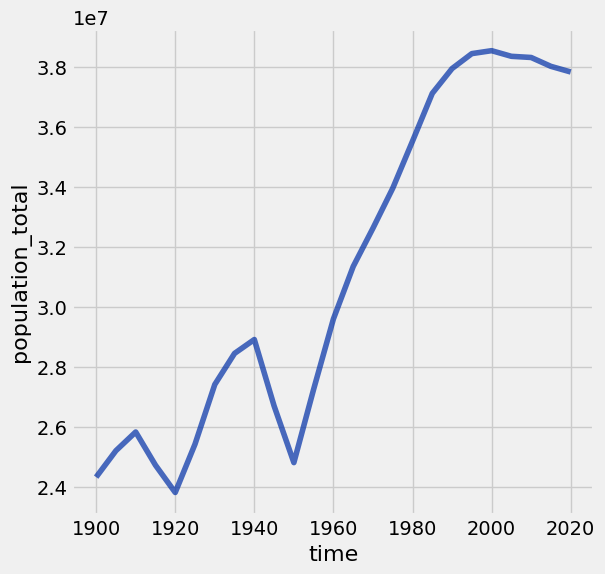

In [37]:
p_five.plot(0, 1)

**Question 2.** Assign `initial` to an array that contains the population for every five year interval from **1900 to 2015** (inclusive). Then, assign `changed` to an array that contains the population for every five year interval from **1905 to 2020** (inclusive). The first array should include both 1900 and 2015, and the second array should include both 1905 and 2020. You should use the `p_five` table to create both arrays, by first filtering the table to only contain the relevant years.

The annual growth rate for a time period is equal to:

$$\left(\left(\frac{\text{Population at end of period}}{\text{Population at start of period}}\right)^{\displaystyle\frac{1}{\text{number of years}}}\right) -1$$

We have provided the code below that uses `initial` and `changed` in order to add a column to `p_five` called `annual_growth`. **Don't worry about the calculation of the growth rates**; run the test below to test your solution.

If you are interested in how we came up with the formula for growth rates, consult the [growth rates](https://inferentialthinking.com/chapters/03/2/1/Growth.html) section of the textbook.


In [38]:
initial = p_five.where('time', are.between_or_equal_to(1900, 2015)).column('population_total')
changed = p_five.where('time', are.between_or_equal_to(1905, 2020)).column('population_total')

p_1900_through_2015 = p_five.where('time', are.below_or_equal_to(2015))
p_five_growth = p_1900_through_2015.with_column('annual_growth', (changed/initial)**0.2-1)
p_five_growth.set_format('annual_growth', PercentFormatter)

time,population_total,annual_growth
1900,"24,340,168",0.71%
1905,"25,221,471",0.49%
1910,"25,844,639",-0.87%
1915,"24,739,041",-0.75%
1920,"23,827,906",1.32%
1925,"25,439,942",1.52%
1930,"27,427,399",0.75%
1935,"28,465,230",0.32%
1940,"28,927,566",-1.58%
1945,"26,713,772",-1.46%


The annual growth rate in Poland has been declining since 1950, as shown in the table below.


In [39]:
# Run this cell to view annual growth rates in Poland since 1950.
p_five_growth.where('time', are.above_or_equal_to(1950)).show()

time,population_total,annual_growth
1950,"24,824,007",1.90%
1955,"27,269,742",1.66%
1960,"29,614,201",1.15%
1965,"31,360,903",0.80%
1970,"32,639,262",0.80%
1975,"33,970,730",0.91%
1980,"35,539,723",0.88%
1985,"37,133,860",0.44%
1990,"37,960,193",0.26%
1995,"38,458,642",0.05%


Next, we'll try to understand what has changed in Poland that might explain the slowing population growth rate. Run the next cell to load three additional tables of measurements about countries over time.


In [40]:
life_expectancy = Table.read_table('./DS/life_expectancy.csv').where('time', are.below(2021))
child_mortality = Table.read_table('./DS/child_mortality.csv').relabel(2, 'child_mortality_under_5_per_1000_born').where('time', are.below(2021))
fertility = Table.read_table('./DS/fertility.csv').where('time', are.below(2021))

The `life_expectancy` table contains a statistic that is often used to measure how long people live, called _life expectancy at birth_. This number, for a country in a given year, [does not measure how long babies born in that year are expected to live](http://blogs.worldbank.org/opendata/what-does-life-expectancy-birth-really-mean). Instead, it measures how long someone would live, on average, if the _mortality conditions_ in that year persisted throughout their lifetime. These "mortality conditions" describe what fraction of people for each age survived the year. So, it is a way of measuring the proportion of people that are staying alive, aggregated over different age groups in the population.


Run the following cells below to see `life_expectancy`, `child_mortality`, and `fertility`. Refer back to these tables as they will be helpful for answering further questions!


In [41]:
life_expectancy.show(3)

geo,time,life_expectancy_years
afg,1800,28.21
afg,1801,28.2
afg,1802,28.19


In [42]:
child_mortality.show(3)

geo,time,child_mortality_under_5_per_1000_born
afg,1800,468.58
afg,1801,468.58
afg,1802,468.58


In [43]:
fertility.show(3)

geo,time,children_per_woman_total_fertility
abw,1800,5.64
abw,1801,5.64
abw,1802,5.64


<!-- BEGIN QUESTION -->

**Question 3.** Is population growing more slowly perhaps because people aren’t living as long? Use the `life_expectancy` table to draw a line graph with the years 1950 and later on the horizontal axis that shows how the _life expectancy at birth_ has changed in Poland.

_Hint_: Make sure you filter the table properly; otherwise, the graph may look funky!


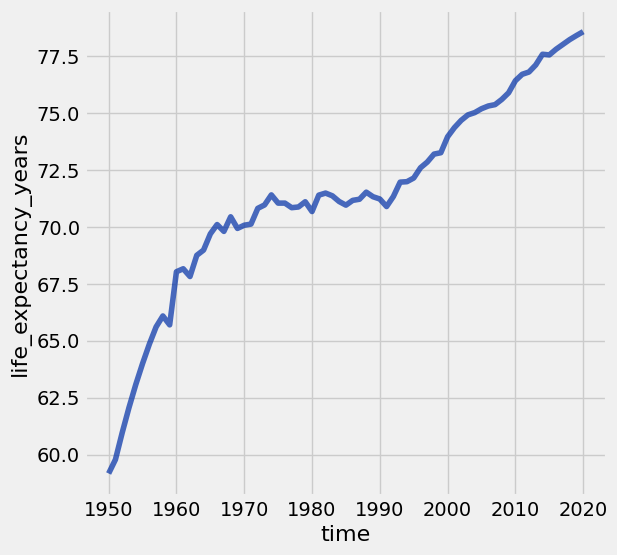

In [44]:
# Fill in code here
poland_life_expectancy = life_expectancy.where('geo', 'pol').where('time', are.above_or_equal_to(1950))
poland_life_expectancy.plot('time', 'life_expectancy_years')

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

**Question 4.** Assuming everything else stays the same, do the trends in life expectancy in the graph above directly explain why the population growth rate decreased since 1950 in Poland? Why or why not?


As the graph shows, life expectancy in Poland has steadily increased since 1950. All other things being equal, increased life expectancy contributes to population growth and is unlikely to be a direct cause of a decline in population growth. Therefore, the trend of increased life expectancy does not directly explain Poland's decline in population growth since 1950. Rather, other factors are likely at play.

<!-- END QUESTION -->

The `fertility` table contains a statistic that is often used to measure how many babies are being born, the _total fertility rate_. This number describes the [number of children a woman would have in her lifetime](https://www.measureevaluation.org/prh/rh_indicators/specific/fertility/total-fertility-rate), on average, if the current rates of birth by age of the mother persisted throughout her child bearing years, assuming she survived through age 49.


**Question 5.** Complete the function `fertility_over_time`. It takes two input arguments, the Alpha-3 code of a country (denoted as `country_code`) and a year to `start` from (denoted as start). It returns a two-column table with the column labels `Year` and `Children per woman`. These columns can be used to generate a line chart of the country’s fertility rate each year, starting from the year given by `start`. The plot should include the start year and all later years that appear in the fertility table.

Then, determine the Alpha-3 code for **Poland**. The code at the very bottom for `poland_code` and the year `1950` are inputted to your `fertility_over_time` function. The function returns a table which we use in order to plot how Poland's fertility rate has changed since `1950`. Note that the function `fertility_over_time` should not return the plot itself – it returns a two column table. The expression that draws the line plot is provided for you; please don’t change it.

_Hint_: Read about `tbl.relabeled` in the [Python Reference](https://www.data8.org/sp24/reference/) to rename columns.


In [52]:
def fertility_over_time(country_code, start):
    """Create a two-column table that describes a country's total fertility rate each year."""
    # It's a good idea (but not required) to use multiple lines in your solution.
    return fertility.where('geo', country_code).where('time', are.above_or_equal_to(start)).select('time', 'children_per_woman_total_fertility').relabeled('time', 'Year').relabeled('children_per_woman_total_fertility', 'Children per woman')


poland_code = 'pol'
fertility_over_time(poland_code, 1950)

Year,Children per woman
1950,3.6
1951,3.62
1952,3.64
1953,3.65
1954,3.64
1955,3.6
1956,3.55
1957,3.47
1958,3.37
1959,3.25


Plotting the fertility rate in Poland since 1950, we see a downward trend.


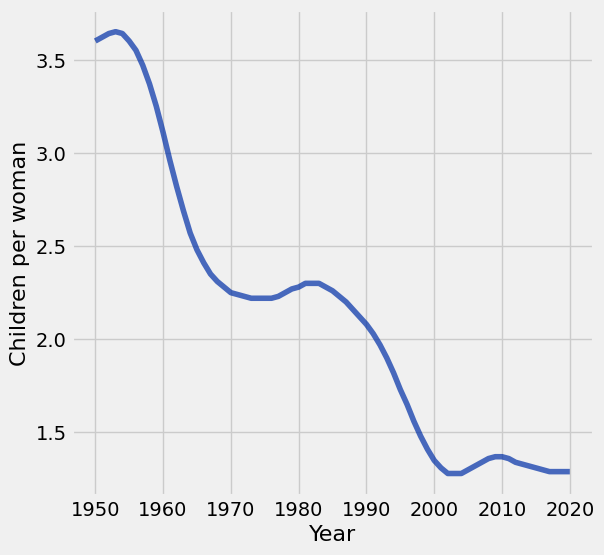

In [53]:
fertility_over_time(poland_code, 1950).plot(0, 1)

<!-- BEGIN QUESTION -->

**Question 6.** Assuming everything else is constant, do the trends in fertility in the graph above help directly explain why the population growth rate decreased from 1950 to 2020 in Poland? Why or why not?


Looking at the graph in question 5, Poland's fertility rate (the number of children per woman) shows a consistent trend from 1950 to 2020. Assuming all other conditions hold, a declining birth rate directly means fewer babies are born. This is the main reason why the declining rate is continuing. This helps directly explain the projections from 1950 to 2020.

<!-- END QUESTION -->

It has been [observed](https://www.ageing.ox.ac.uk/download/143) that lower fertility rates are often associated with lower child mortality rates. We can see if this association is evident in Poland by plotting the relationship between total fertility rate and [child mortality rate per 1000 children](https://en.wikipedia.org/wiki/Child_mortality).


**Question 7.** Create a table `poland_since_1950` that contains one row per year starting with 1950 and:

- A column `Year` containing the year
- A column `Children per woman` describing total fertility in Poland that year
- A column `Child deaths per 1000 born` describing child mortality in Poland that year


In [55]:
pol_fertility = fertility_over_time(poland_code, 1950)  # Try starting with the table you built already!
# It's a good idea (but not required) to use multiple lines in your solution.
pol_child_mortality = child_mortality.where('geo', 'pol').where('time', are.above_or_equal_to(1950)).select('time', 'child_mortality_under_5_per_1000_born').relabeled('time', 'Year').relabeled('child_mortality_under_5_per_1000_born', 'Child deaths per 1000 born')
pol_fertility_and_child_mortality = pol_fertility.join('Year', pol_child_mortality)
poland_since_1950 = pol_fertility_and_child_mortality
poland_since_1950

Year,Children per woman,Child deaths per 1000 born
1950,3.6,164.08
1951,3.62,177.18
1952,3.64,140.16
1953,3.65,127.65
1954,3.64,118.9
1955,3.6,110.38
1956,3.55,94.19
1957,3.47,86.72
1958,3.37,81.28
1959,3.25,72.1


Run the following cell to generate a scatter plot from the `poland_since_1950` table you created.

The plot uses **color** to encode data about the `Year` column. The colors, ranging from dark blue to white, represent the passing of time between 1950 and 2020. For example, a point on the scatter plot representing data from the 1950s would appear as **dark blue** and a point from the 2010s would appear as **light blue**.


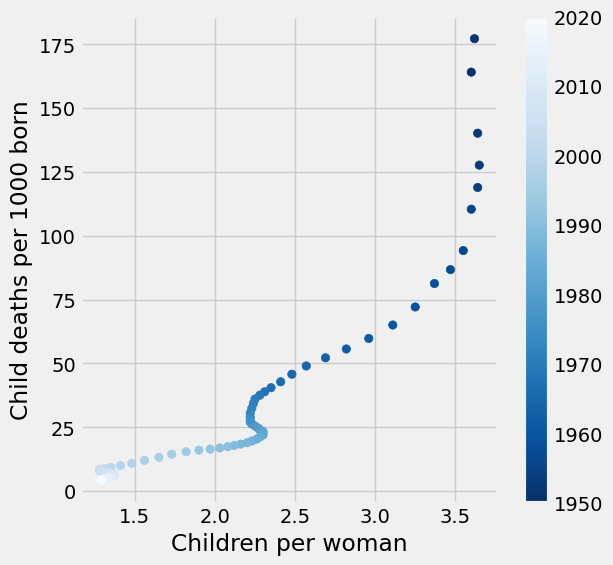

In [56]:
x_births = poland_since_1950.column("Children per woman")
y_deaths = poland_since_1950.column("Child deaths per 1000 born")
time_colors = poland_since_1950.column("Year")

plots.figure(figsize=(6,6))
plots.scatter(x_births, y_deaths, c=time_colors, cmap="Blues_r")
plots.colorbar()
plots.xlabel("Children per woman")
plots.ylabel("Child deaths per 1000 born");

<!-- BEGIN QUESTION -->

**Question 8.** In one or two sentences, describe the association (if any) that is illustrated by this scatter plot. Does the diagram show any causal relation between between fertility and child mortality?


This scatterplot demonstrates a strong negative correlation between "births per woman" and "infant mortality rate per 1,000 newborns" in Poland. In other words, as the number of births decreases over time, so does the infant mortality rate. The points on the graph move diagonally from upper right to lower left, shifting from dark blue (past) to light blue (recent).

However, this diagram alone does not conclusively demonstrate a direct causal relationship between fertility and infant mortality. While the two variables show a strong correlation, it is more likely that multiple complex social and economic factors, such as economic development, increased access to healthcare, rising education levels, and improved sanitation, are simultaneously influencing both variables. For example, a lower infant mortality rate might lead parents to have fewer children, but this is more of an indirect interaction than a direct causal relationship. While this graph visually demonstrates the link between these trends, it is difficult to say that one variable directly "causes" the other.

<!-- END QUESTION -->

_Optional food for thought_: What other context or information you would need in order to better understand the factors affecting life expectancy, child mortality, and fertility?


## Submission

Make sure you have run all cells in your notebook in order before running the cell below, so that all images/graphs appear in the output. The cell below will generate a pdf file for you to submit. **Please save before exporting!**

In [ ]:
# should change the directory and file name matching to yours
!jupyter nbconvert './DS/lab24(SSU).ipynb' --to pdf